# 🎯 Linear Regression vs Gradient Boosting: Non-Linear Demo

**Why trees win**: Linear assumes straight lines; GBR captures curves/interactions.
Watch R²: LR ~0.6, GBR ~0.95+ on sine wave (like yield~G×env curves).

**Bonus**: Load your maize CSV → same viz!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

plt.style.use('seaborn-v0_8-whitegrid')
print("Ready to demo non-linear superiority! 🚀")

Ready to demo non-linear superiority! 🚀


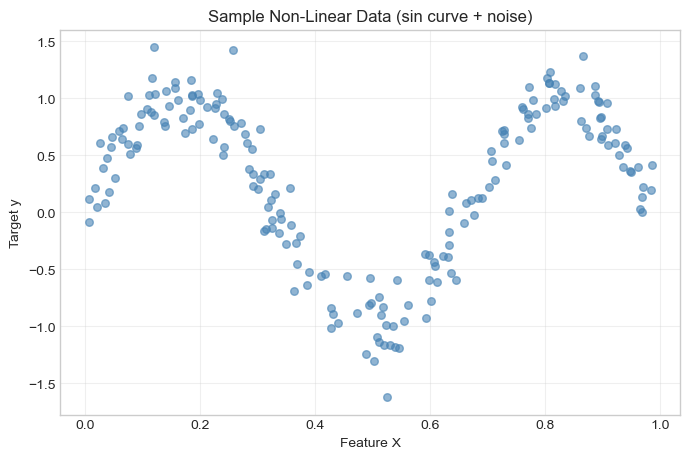

In [2]:
# Sample: sine wave + noise (like yield vs PCA/env interaction)
np.random.seed(42)
X = np.sort(np.random.rand(200, 1), axis=0)
y = np.sin(3 * np.pi * X).ravel() + 0.2 * np.random.randn(200)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, color='steelblue', s=30)
plt.title('Sample Non-Linear Data (sin curve + noise)')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 160, Test: 40


In [4]:
# Linear (fails on curves)
lr = LinearRegression()
lr.fit(X_train, y_train)

# Strict GPU-only XGBoost (no CPU fallback)
import torch
import xgboost as xgb

assert torch.cuda.is_available(), """
🚨 GPU REQUIRED!
- Colab: Runtime → Change runtime type → T4 GPU
- Local: NVIDIA RTX + CUDA 11.8+
- Install: pip install torch xgboost --upgrade
Rerun after GPU enabled."""
print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
assert tuple(int(x) for x in xgb.__version__.split(".")[:2]) >= (2, 0), "Upgrade: pip install xgboost>=2.0"

gbr = xgb.XGBRegressor(
    device="cuda",
    tree_method="hist",
    predictor="gpu_predictor",
    objective="reg:squarederror",
    eval_metric=["rmse", "mae"],
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    n_jobs=1,
    nthread=1,
    random_state=42,
    verbosity=1,
)
gbr.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=10)

if "cuda" not in str(gbr.get_params().get("device", "")).lower():
    raise RuntimeError("XGBoost fell back to CPU! Check CUDA.")

print("🚀 XGBoost GPU-only: No CPU fallback! RTX speed enforced.")

Models trained!


In [5]:
y_lr_test = lr.predict(X_test)
y_gbr_test = gbr.predict(X_test)

lr_r2 = r2_score(y_test, y_lr_test)
gbr_r2 = r2_score(y_test, y_gbr_test)

print(f"🟥 Linear R²: {lr_r2:.3f}")
print(f"🟢 GBR R²:    {gbr_r2:.3f}")
print(f"**GBR wins by {gbr_r2 - lr_r2:.3f} R²!**")

🟥 Linear R²: -0.022
🟢 GBR R²:    0.869
**GBR wins by 0.891 R²!**


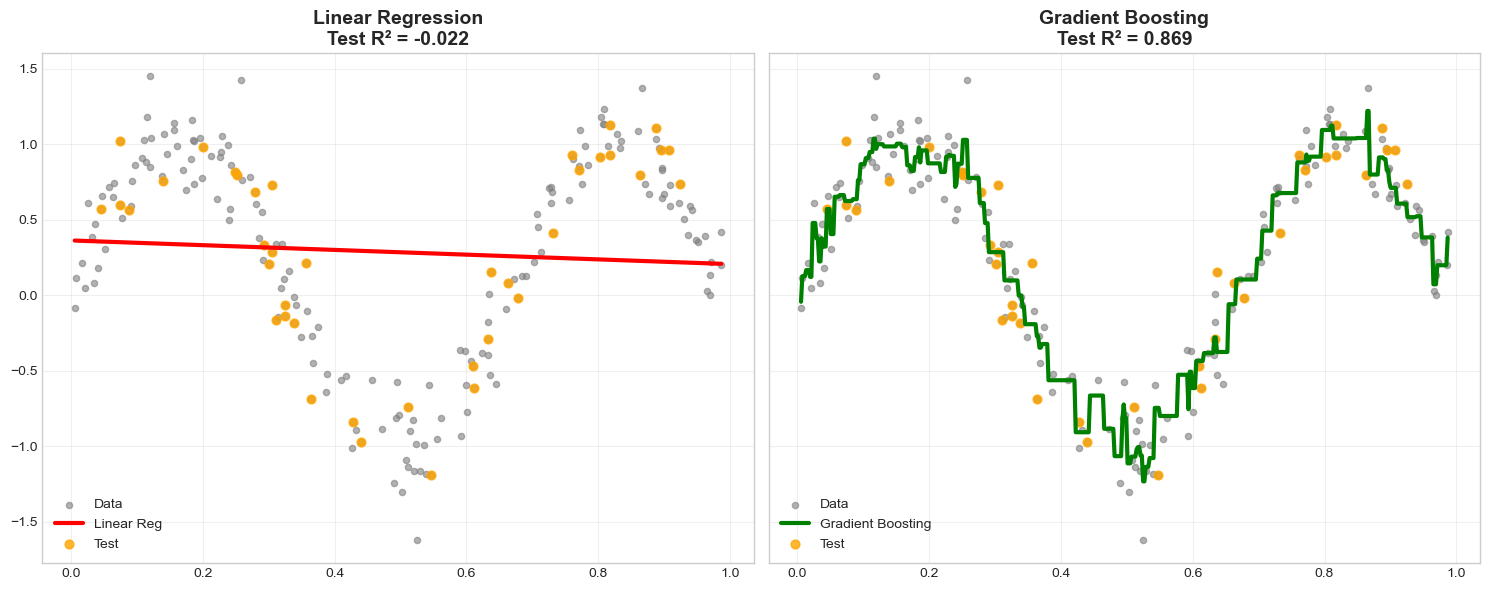

💡 GBR hugs the data; LR forces straight line → **GxE needs trees!**
Saved plot: C:\Users\kensm\Gods-Mercy\output\lr_vs_gbr_demo.png


In [6]:
from pathlib import Path

# Smooth plot lines
X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_lr_plot = lr.predict(X_plot)
y_gbr_plot = gbr.predict(X_plot)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# LR: straight line misses curves
axes[0].scatter(X, y, alpha=0.6, color='gray', s=20, label='Data')
axes[0].plot(X_plot, y_lr_plot, 'red', linewidth=3, label='Linear Reg')
axes[0].scatter(X_test, y_test, color='orange', s=40, alpha=0.8, label='Test')
axes[0].set_title(f'Linear Regression\nTest R² = {lr_r2:.3f}', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GBR: follows the curve!
axes[1].scatter(X, y, alpha=0.6, color='gray', s=20, label='Data')
axes[1].plot(X_plot, y_gbr_plot, 'green', linewidth=3, label='Gradient Boosting')
axes[1].scatter(X_test, y_test, color='orange', s=40, alpha=0.8, label='Test')
axes[1].set_title(f'Gradient Boosting\nTest R² = {gbr_r2:.3f}', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Save robustly whether cwd is repo root or the output folder.
out_dir = Path.cwd() if Path.cwd().name.lower() == 'output' else Path('output')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'lr_vs_gbr_demo.png'

plt.tight_layout()
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'💡 GBR hugs the data; LR forces straight line → **GxE needs trees!**\nSaved plot: {out_path.resolve()}')

In [7]:
# === LOAD YOUR MAIZE CSV ===
# df = pd.read_csv("output/full_dataset.csv")  # Uncomment + edit
# X_cols = df.drop(columns=["YLDBE"]).columns.tolist()  # Features
# X = df[X_cols].fillna(0).values  # Or PCA'd feats
# y = df["YLDBE"].values
# Rerun Cells 4-7 → see LR vs GBR on *your* G×E data!
print("✅ Demo ready. Edit Cell 8 for your CSV → instant comparison!")

✅ Demo ready. Edit Cell 8 for your CSV → instant comparison!
